In [1]:
%run shared_imports.py

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)

In [3]:
def json_to_series(text):
    keys, values = zip(*[item for item in text['data'].items()])
    return pd.Series(values, index=keys)


In [4]:
query = select(Round.map_name, Feedback.json).join(Round).filter(
    or_(
        Feedback.key_name=='vampire_success',
        Feedback.key_name=='changeling_success',
        Feedback.key_name=='traitor_success'
    ),
    Feedback.datetime >= datetime(2024, 1, 1),
    Feedback.datetime <= datetime(2024, 10, 1),
)

df = pd.read_sql_query(query, session.connection())

In [7]:
normalized = pd.concat([df, df['json'].apply(json_to_series)], axis=1).drop(['json'], axis=1)

In [17]:
normalized.fillna(0).groupby(['map_name']).sum().astype(int)

,FAIL,SUCCESS
map_name,,
CereStation,1156,384
Cyberiad,8183,2978
Delta,1693,547
EmeraldStation,395,151
MetaStation,1679,569


In [31]:
# Let's doublecheck the math
for station in ["CereStation", "Cyberiad", "Delta", "EmeraldStation", "MetaStation"]:
    result = data[station].SUCCESS / (data[station].FAIL + data[station].SUCCESS)
    print(f"{station}: {result}")

CereStation: 0.24935064935064935
Cyberiad: 0.26682196935758445
Delta: 0.24419642857142856
EmeraldStation: 0.2765567765567766
MetaStation: 0.2531138790035587


In [21]:
data = normalized.fillna(0).groupby(['map_name']).sum().astype(int)
data = data.transpose()

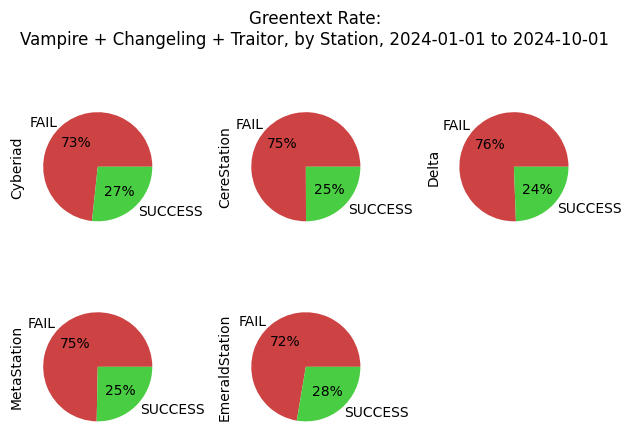

In [68]:
fig, axes = plt.subplots(nrows=2, ncols=3)

plt.suptitle("Greentext Rate:\nVampire + Changeling + Traitor, by Station, 2024-01-01 to 2024-10-01")
data['Cyberiad'].plot(ax=axes[0, 0], kind='pie', autopct='%1.0f%%', colors=["#cd4242", "#49cd42"])
data['CereStation'].plot(ax=axes[0, 1], kind='pie', autopct='%1.0f%%', colors=["#cd4242", "#49cd42"])
data['Delta'].plot(ax=axes[0, 2], kind='pie', autopct='%1.0f%%', colors=["#cd4242", "#49cd42"])
data['MetaStation'].plot(ax=axes[1, 0], kind='pie', autopct='%1.0f%%', colors=["#cd4242", "#49cd42"])
data['EmeraldStation'].plot(ax=axes[1, 1], kind='pie', autopct='%1.0f%%', colors=["#cd4242", "#49cd42"])

fig.delaxes(axes[1][2])
fig.tight_layout()

plt.savefig('solo_antag_winrate_per_maps_2024-01-01_2024-10-01.png')

In [19]:
plt.rc('axes', titlesize=10)

In [20]:
query = select(Round.map_name, Feedback.json).join(Round).filter(
    or_(
        Feedback.key_name=='vampire_success',
    ),
    Feedback.datetime >= datetime(2024, 1, 1),
    Feedback.datetime <= datetime(2024, 10, 1),
)

df = pd.read_sql_query(query, session.connection())

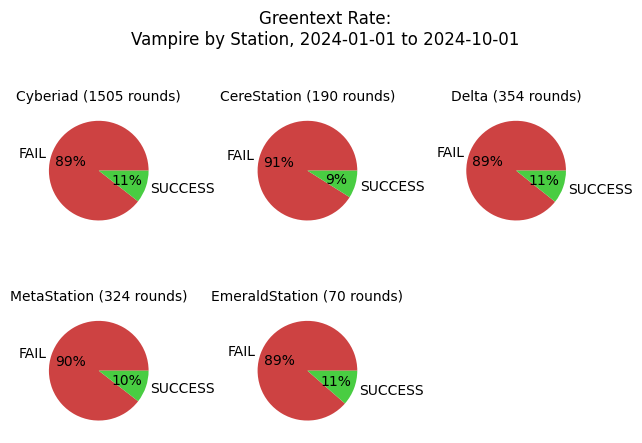

In [21]:
normalized = pd.concat([df, df['json'].apply(json_to_series)], axis=1).drop(['json'], axis=1)
normalized.fillna(0).groupby(['map_name']).sum().astype(int)
data = normalized.fillna(0).groupby(['map_name']).sum().astype(int)
data = data.transpose()
fig, axes = plt.subplots(nrows=2, ncols=3)

defaults = {
    'kind': 'pie',
    'autopct': '%1.0f%%',
    'colors': ["#cd4242", "#49cd42"],
    'ylabel': '',
}

plt.suptitle("Greentext Rate:\nVampire by Station, 2024-01-01 to 2024-10-01")

for map_name, loc in (
    ['Cyberiad', axes[0, 0]],
    ['CereStation', axes[0, 1]],
    ['Delta', axes[0, 2]],
    ['MetaStation', axes[1, 0]],
    ['EmeraldStation', axes[1, 1]]
):
    map_total = data[map_name].sum()
    data_plot = data[map_name].plot(ax=loc, title=f'{map_name} ({map_total} rounds)', **defaults)


fig.delaxes(axes[1][2])
fig.tight_layout()

plt.savefig('vampire_winrate_per_maps_2024-01-01_2024-10-01.png')

In [22]:
query = select(Round.map_name, Feedback.json).join(Round).filter(
    or_(
        Feedback.key_name=='changeling_success',
    ),
    Feedback.datetime >= datetime(2024, 1, 1),
    Feedback.datetime <= datetime(2024, 10, 1),
)

df = pd.read_sql_query(query, session.connection())

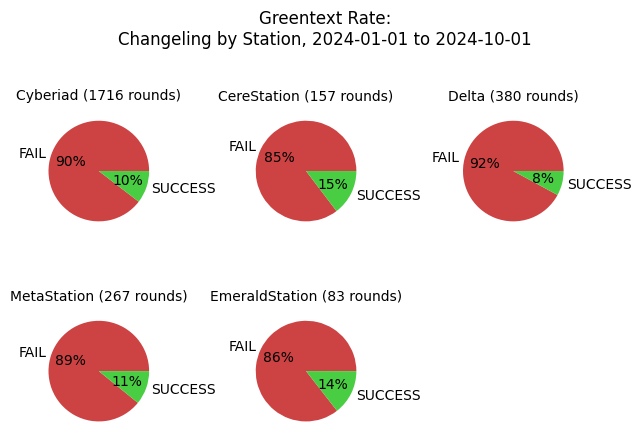

In [23]:
normalized = pd.concat([df, df['json'].apply(json_to_series)], axis=1).drop(['json'], axis=1)
normalized.fillna(0).groupby(['map_name']).sum().astype(int)
data = normalized.fillna(0).groupby(['map_name']).sum().astype(int)
data = data.transpose()
fig, axes = plt.subplots(nrows=2, ncols=3)

defaults = {
    'kind': 'pie',
    'autopct': '%1.0f%%',
    'colors': ["#cd4242", "#49cd42"],
    'ylabel': '',
}

plt.suptitle("Greentext Rate:\nChangeling by Station, 2024-01-01 to 2024-10-01")

for map_name, loc in (
    ['Cyberiad', axes[0, 0]],
    ['CereStation', axes[0, 1]],
    ['Delta', axes[0, 2]],
    ['MetaStation', axes[1, 0]],
    ['EmeraldStation', axes[1, 1]]
):
    map_total = data[map_name].sum()
    data_plot = data[map_name].plot(ax=loc, title=f'{map_name} ({map_total} rounds)', **defaults)


fig.delaxes(axes[1][2])
fig.tight_layout()

plt.savefig('changeling_winrate_per_maps_2024-01-01_2024-10-01.png')

In [24]:
query = select(Round.map_name, Feedback.json).join(Round).filter(
    or_(
        Feedback.key_name=='traitor_success',
    ),
    Feedback.datetime >= datetime(2024, 1, 1),
    Feedback.datetime <= datetime(2024, 10, 1),
)

df = pd.read_sql_query(query, session.connection())

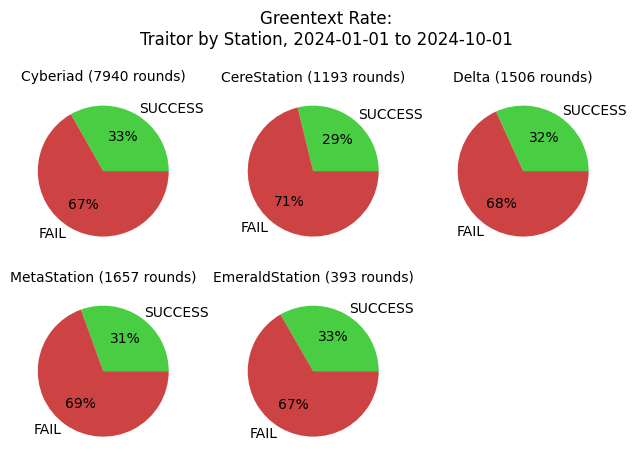

In [25]:
normalized = pd.concat([df, df['json'].apply(json_to_series)], axis=1).drop(['json'], axis=1)
normalized.fillna(0).groupby(['map_name']).sum().astype(int)
data = normalized.fillna(0).groupby(['map_name']).sum().astype(int)
data = data.transpose()
fig, axes = plt.subplots(nrows=2, ncols=3)

defaults = {
    'kind': 'pie',
    'autopct': '%1.0f%%',
    'colors': ["#49cd42", "#cd4242"], # colors reversed for this query for some raisin
    'ylabel': '',
}

plt.suptitle("Greentext Rate:\nTraitor by Station, 2024-01-01 to 2024-10-01")

for map_name, loc in (
    ['Cyberiad', axes[0, 0]],
    ['CereStation', axes[0, 1]],
    ['Delta', axes[0, 2]],
    ['MetaStation', axes[1, 0]],
    ['EmeraldStation', axes[1, 1]]
):
    map_total = data[map_name].sum()
    data_plot = data[map_name].plot(ax=loc, title=f'{map_name} ({map_total} rounds)', **defaults)

fig.delaxes(axes[1][2])
fig.tight_layout()

plt.savefig('traitor_winrate_per_maps_2024-01-01_2024-10-01.png')